# Positional Encoding

## Start with the problem: the same words can mean different things in a different order

“The dog chased the cat” and “The cat chased the dog” contain the same words but assign different roles. A model must be able to use their order, not merely recognize that dog, cat, and chased are present.

Unrestricted self-attention based only on content compares representations but has no explicit first-position or distance coordinate. Rearranging the input rows rearranges its output rows correspondingly. To make sequence structure available, a Transformer needs positional information or another architectural source of order.

A **positional encoding** supplies numerical features associated with sequence positions. Common designs add fixed or learned vectors to embeddings, add distance-dependent attention biases, or rotate query/key coordinate pairs. These designs place order information at different points in the computation.

We will construct sinusoidal vectors by hand, add them to repeated-token embeddings, compare learned and relative designs, and inspect practical indexing decisions. The [code companion](28_Positional_Encoding.ipynb) checks a width-four encoding and contrasts it with a learned table. [Transformers](27_Transformers_Notes.ipynb) shows where positions enter a block.


## Distinguish permutation equivariance from ignoring every position

Let $P$ be a matrix that reorders sequence rows. Without position features or a position-dependent mask, self-attention satisfies the permutation relationship:

$$\operatorname{Attention}(PX)=P\operatorname{Attention}(X).$$

This is **equivariance**: outputs follow the reordered inputs. It does not say every output is identical or that the layer cannot distinguish different token content. It says the layer has no content-independent label for which row was originally first.

For a scalar identity-projection example with rows $[1,2]$, scores are $[[1,2],[2,4]]$. Reading values $[1,2]$ gives outputs approximately $[1.731059,1.880797]$. Swap the inputs to $[2,1]$ and the outputs swap too.

If an order-insensitive mean pools those outputs, both permutations have the same result. Position features can break this content-only symmetry. A causal mask also introduces asymmetric prefix structure, so the unrestricted-attention statement must not be applied blindly to a masked model.


## Add content and position coordinate by coordinate

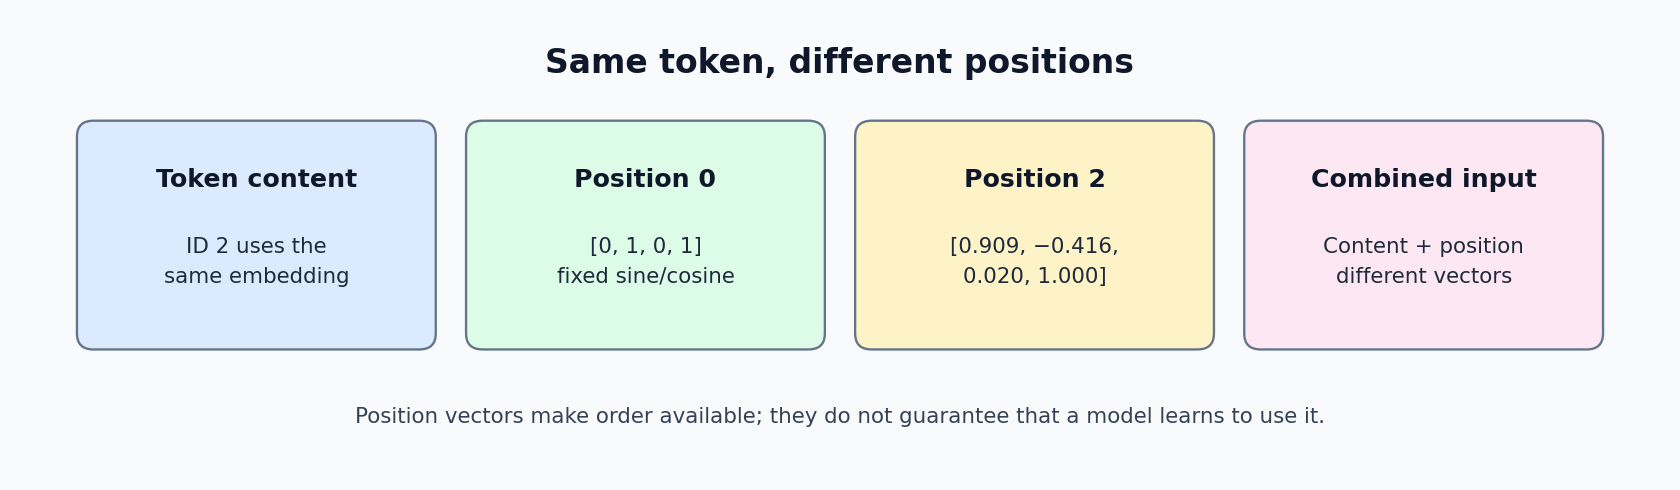

An additive absolute scheme forms:

$$X_{b,p}=E_{id_{b,p}}+PE_p.$$

The two vectors must have the same width. Their sum also has that width, so the block's model dimension does not change.

| Quantity | What it represents | Shared across what? |
| --- | --- | --- |
| Token embedding | Content associated with a token ID | Occurrences of the same ID |
| Position vector | Position index | Examples using that index |
| Combined representation | Content plus available order information | Depends on both |

For a fixed token embedding, different position vectors yield different sums. But if two different content vectors happen to offset a position difference, additive representations are not guaranteed to be globally unique. The goal is useful structure for learning, not an infallible numerical identifier for every possible token/position pair.


## Read the sinusoidal formula one symbol at a time

For even model width $D$, the classic fixed encoding uses:

$$PE_{p,2i}=\sin\left(\frac{p}{10000^{2i/D}}\right),$$
$$PE_{p,2i+1}=\cos\left(\frac{p}{10000^{2i/D}}\right).$$

| Symbol | Meaning |
| --- | --- |
| $p$ | Zero-based position index |
| $D$ | Number of coordinates in the encoding |
| $i$ | Frequency-pair index, from zero to $D/2-1$ |
| $2i$ | Coordinate receiving sine |
| $2i+1$ | Coordinate receiving cosine |
| $10000^{2i/D}$ | Frequency-dependent denominator |

Each pair records the same angle through sine and cosine. Different denominators produce different rates of variation. Early pairs vary faster with position; later pairs vary more slowly.

This is a fixed feature construction. There are no learned entries in this table itself, although the surrounding model still learns how to use the features. The constant 10000 is part of this particular design, not a universal requirement for representing order.


## Derive the width-four vectors in the companion

With $D=4$, pair $i=0$ has denominator $10000^0=1$, while pair $i=1$ has denominator $10000^{1/2}=100$. Therefore:

$$PE_p=[\sin(p),\cos(p),\sin(p/100),\cos(p/100)].$$

| Position | $\sin(p)$ | $\cos(p)$ | $\sin(p/100)$ | $\cos(p/100)$ |
| --- | --- | --- | --- | --- |
| 0 | 0.000000 | 1.000000 | 0.000000 | 1.000000 |
| 1 | 0.841471 | 0.540302 | 0.010000 | 0.999950 |
| 2 | 0.909297 | -0.416147 | 0.019999 | 0.999800 |
| 10 | -0.544021 | -0.839072 | 0.099833 | 0.995004 |

Position zero is not the zero vector: its cosine coordinates are one. The slow pair hardly changes between positions zero and two, while the fast pair changes substantially. Using multiple pairs supplies structure at several scales.

The angles are in radians. Substituting degrees would produce a different encoding and fail the companion's expected position-one calculation.


## See fast and slow coordinates across a longer interval

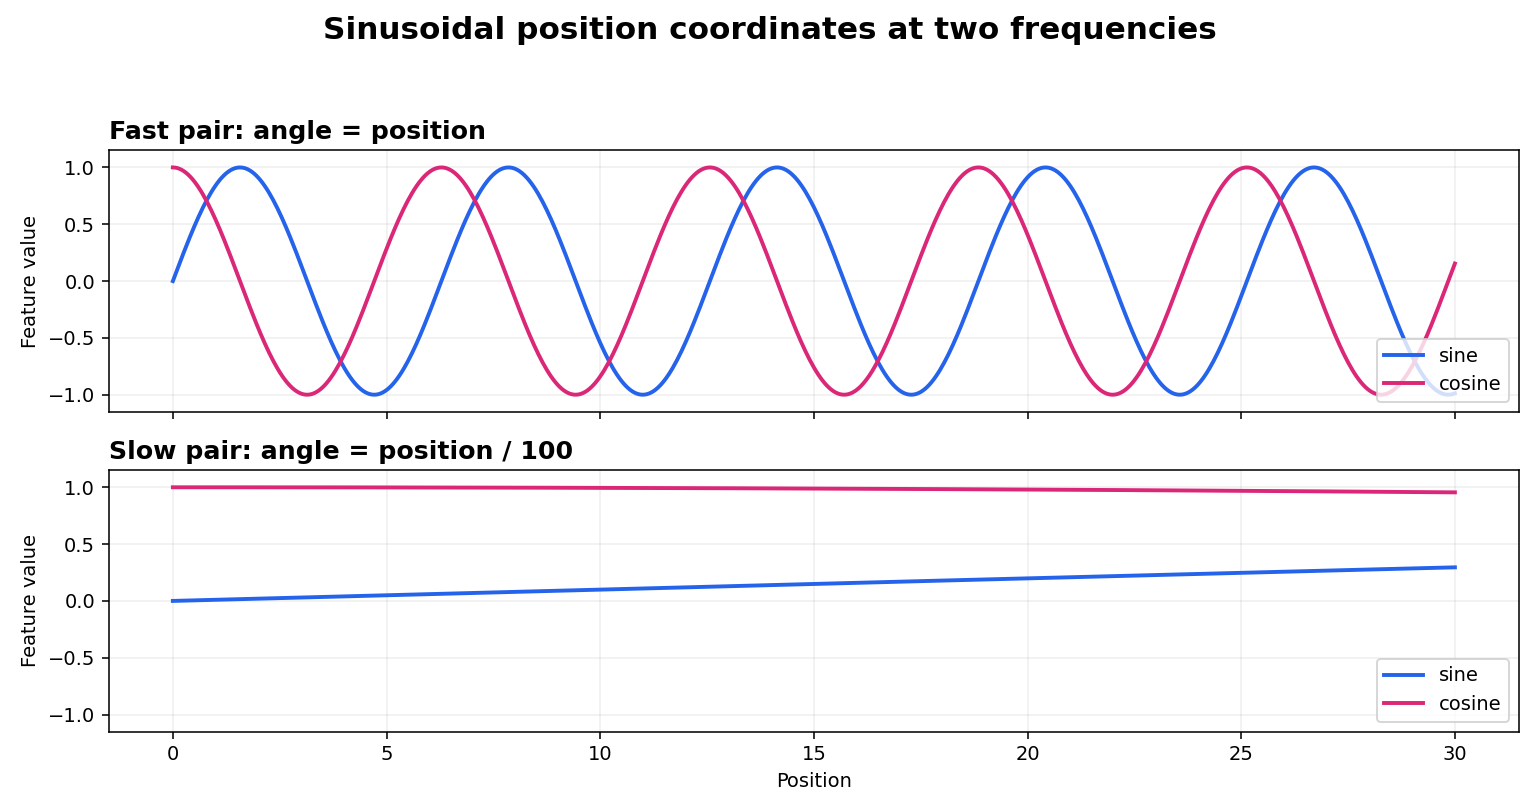

The first pair completes several oscillations across this interval. The second pair moves only through angles from zero to 0.3 radians. Together they provide more information than a single scalar position feature.

Periodicity does not mean the model knows a token's role or understands distance without learning. These functions are ingredients supplied to the model. Their usefulness depends on the projection weights, task, and training positions.

Each complete sine/cosine pair has squared norm one because $\sin^2\theta+\cos^2\theta=1$. The width-four position vector therefore has squared norm two and norm $\sqrt2$, at every position. Its direction changes with position even though its norm stays constant.

This constant norm belongs to the positional vector alone. Adding a token embedding introduces a cross term, so the combined representation need not have constant norm across positions.


## Combine repeated tokens and calculate the difference

Choose a teaching token embedding $e=[0.2,-0.1,0.3,0]$ for token ID 2. Add position vectors at zero and two:

| Coordinate | Content | Position 0 | Combined at 0 | Position 2 | Combined at 2 |
| --- | --- | --- | --- | --- | --- |
| 0 | 0.2 | 0 | 0.2 | 0.909297 | 1.109297 |
| 1 | -0.1 | 1 | 0.9 | -0.416147 | -0.516147 |
| 2 | 0.3 | 0 | 0.3 | 0.019999 | 0.319999 |
| 3 | 0 | 1 | 1 | 0.999800 | 0.999800 |

The content is identical, but the combined vectors differ. The code companion similarly places token ID 2 at the first and third positions and checks that their combined representations are not equal.

The companion's embedding table is initialized by the library; it is not the hand-chosen vector in this table. The fixed position values and distinction between the two repeated occurrences are the mechanisms being illustrated.


## Explain why paired functions expose offset structure

For angle $\theta=p\omega$ and offset angle $\delta=\Delta\omega$, trigonometric identities give:

$$\sin(\theta+\delta)=\sin\theta\cos\delta+\cos\theta\sin\delta,$$
$$\cos(\theta+\delta)=\cos\theta\cos\delta-\sin\theta\sin\delta.$$

For a fixed offset $\Delta$, the pair at position $p+\Delta$ can be expressed as a linear transformation of the pair at position $p$. The coefficients depend on the offset and frequency rather than the starting position.

For the fast pair at $p=1$ and $\Delta=1$, the sine identity gives $2\sin(1)\cos(1)\approx0.909297$, matching $\sin(2)$. The cosine identity gives $\cos^2(1)-\sin^2(1)\approx-0.416147$, matching $\cos(2)$.

This structure makes relative offsets available through relationships among fixed features. It does not guarantee that a trained attention projection recovers the offset exactly or generalizes reliably to unfamiliar lengths. Providing a mathematical relationship is different from demonstrating learned task behavior.


## Compare fixed vectors with a learned absolute table

A learned table stores $P\in\mathbb R^{L_{max}\times D}$. Position $p$ looks up row $P_p$, which is added to token content. The table contributes $L_{max}D$ learnable parameters.

| Property | Fixed sinusoidal | Learned absolute |
| --- | --- | --- |
| Position parameters | None in the fixed formula | One learned vector per table row |
| Values before training | Deterministic functions | Initialized table entries |
| New numeric index | Formula can be evaluated | Must exist or be explicitly supported |
| Training signal | Adjusts surrounding model | Also adjusts position rows |
| Longer-context reliability | Must be evaluated | Must be evaluated |

The companion constructs a learned table with eight rows and width four, contributing 32 parameters. Only the first three rows are selected by its three-position example. Creating an eight-row table does not mean the model has learned useful behavior at every row.

Extending a table by initialization or interpolation is a model change that requires validation. A supported index range and a successfully trained position range are distinct concepts.


## Follow one learning step into a learned position vector

Choose content $e=[0.3,-0.1]$ and learned position row $P_0=[0.1,0.2]$. Their sum is $x=[0.4,0.1]$. Let a fixed scalar head use weight $w=[1,-2]$ with no bias:

$$\hat y=w\cdot x=0.4-2(0.1)=0.2.$$

For target one and squared error, $L=(0.2-1)^2=0.64$. The gradient into $x$ is $2(0.2-1)w=[-1.6,3.2]$. Because addition has derivative one, the same gradient reaches the selected position row.

At learning rate 0.1, updating only that row gives $P_0^{new}=[0.26,-0.12]$. Then $x^{new}=[0.56,-0.22]$, prediction is $0.56+0.44=1$, and this single-example loss becomes zero.

This carefully selected example isolates the position update; it is not a training recipe. Full training also adjusts content embeddings and the head, balancing many examples. A fixed sinusoidal vector would not receive parameter updates, although gradients still pass through its addition to the learned content and downstream network.


## Put position into attention scores or query/key geometry

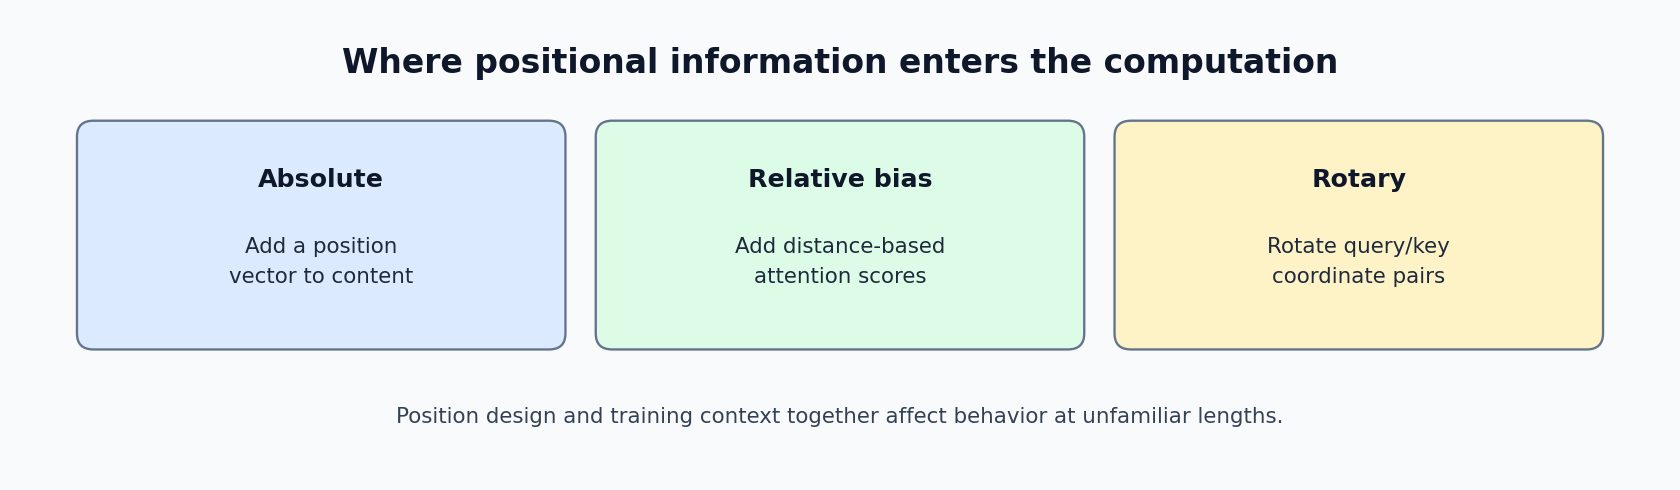

An additive relative score bias can take the form:

$$s_{p,j}=\frac{q_p\cdot k_j}{\sqrt{d_k}}+b_{p-j}.$$

If content scores are both zero but a nearby key receives bias zero and a distant key bias -1, softmax gives approximately $[0.731059,0.268941]$. The bias changes the read before values are combined. Its direction and size are design choices, not a universal rule that nearby positions are better.

A rotary-style construction rotates selected query/key coordinate pairs by position-dependent angles. For a two-coordinate pair, $R(\theta)[1,0]=[\cos\theta,\sin\theta]$. Rotating the same base query at position one and key at position two with angle equal to position gives dot product $\cos(1-2)=\cos(1)\approx0.540302$.

Rotations preserve each pair's norm while making interactions depend on relative angle. Practical models use multiple frequencies and implementation-specific details; this pair example explains geometry rather than claiming complete long-context behavior.


## Keep batch broadcasting and width assumptions visible

The companion creates position vectors with shape $(3,4)$ and adds a batch axis to obtain $(1,3,4)$. Token vectors also have shape $(1,3,4)$. For a larger batch, a shared position tensor can broadcast across examples that use the same position indices.

| Object | General shape | Companion shape |
| --- | --- | --- |
| Token IDs | $(B,L)$ | $(1,3)$ |
| Token vectors | $(B,L,D)$ | $(1,3,4)$ |
| Shared fixed positions | $(1,L,D)$ | $(1,3,4)$ |
| Combined vectors | $(B,L,D)$ | $(1,3,4)$ |

The saved `sinusoidal_positions` helper assumes an even width. Its sine and cosine assignments use the same frequency count; an odd width gives different numbers of even and odd coordinates. The notes use width four throughout, so they match that helper. Supporting odd widths would require an explicit assignment decision.

Ensure position vectors match the content tensor's device and intended numerical type. Adding a position tensor along the wrong axis can create a valid broadcast that means something entirely different.


## Handle padding, truncation, and generation indices deliberately

Padding supplies storage positions, not semantic tokens. With right padding, valid positions can keep indices $0,1,2$ even if two padding slots follow. With left padding, a valid sequence might be stored in slots $2,3,4$; decide whether its semantic position IDs remain $0,1,2$ or include the storage offset.

| Situation | Indexing question |
| --- | --- |
| Variable-length batch | Are indices per example or shared storage slots? |
| Left padding | Do valid tokens keep intended semantic positions? |
| Truncated window | Do positions restart or preserve a global offset? |
| Cached generation | Does the new token use the next prefix index? |
| Encoder–decoder model | Are source and target positions indexed separately? |

No single offset policy fits every task. The policy used at inference should agree with training and the chosen architecture. A cached token should not silently be assigned position zero each time unless that is an intentional design.

Position information does not replace padding or causal masks. A model can know an index and still attend to a prohibited future token if the availability mask is wrong.


## Understand why a defined formula is not a generalization guarantee

A sinusoidal formula can produce a vector for position 10000 even if training used only positions below 100. This establishes mathematical availability, not reliable predictions there.

The model's projections, interactions, task patterns, and training context all shape what it learns. New lengths can introduce unfamiliar combinations of frequencies, more distractors, different attention concentration, and a different distribution of distances.

Likewise, a relative design can define offsets outside the training range but still perform poorly on them. Learned buckets may deliberately group distant offsets, losing exact-distance resolution. A longer configured context can increase computation without supplying evidence that the model uses the additional history correctly.

Evaluate on the lengths and dependency distances relevant to the task. Report whether longer inputs were present during training, how position indices are handled, and whether the evaluation changes the information available to the prediction.


## Diagnose position errors before blaming attention

| Symptom | First investigation |
| --- | --- |
| Repeated tokens have identical combined vectors | Missing or repeated position indices |
| Encoding matches a different pattern than expected | Radians, denominator, and coordinate order |
| Shape error at an odd width | Sine/cosine frequency assignment |
| Table lookup fails on long inputs | Supported position range |
| Cached generation drifts immediately | Prefix offset and cache indexing |
| Results change with left padding | Position IDs and padding masks |

The companion confirms the position-one values, width-four shape, and difference between repeated token occurrences. It prints an initialized learned-table sample. It does not train a model or test extrapolation, so its checks should not be interpreted as evidence of long-context accuracy.

For an experiment, train an order-sensitive task with fixed and learned positions under the same split, then compare familiar and unfamiliar lengths. Keep model capacity and available context comparable so the position design is the change being investigated.


## Practice the coordinates and retain the purpose

1. What is the width-four sinusoidal vector at position zero?
2. What denominator is used by the second frequency pair at width four?
3. Does adding position double the model width?
4. How many parameters are in a learned table with 20 positions and width eight?
5. Does evaluating a fixed formula at a new index prove good predictions there?

**Answers.** Position zero is $[0,1,0,1]$. The second denominator is 100. Addition preserves width; concatenation would change it. The learned table has $20(8)=160$ parameters. A defined vector does not establish reliable learned behavior at the new index.

**Remember:** positions make order available through representation features or pairwise interactions. The model still needs to learn how that order helps the task, and index handling must remain consistent across training and use.

Continue with [Multi-Head Attention](29_Multi_Head_Attention_Notes.ipynb), which follows several learned query/key/value spaces in parallel.


## Connect this lesson to a trained Transformer

<div style="background:#DBEAFE;border-left:6px solid #2563EB;padding:16px;border-radius:8px"><b>Complete learning experience.</b> The [lesson 32 code project](32_GPT_and_Autoregressive_Models.ipynb) now trains a small causal Transformer, selects a checkpoint on validation sentences, evaluates excluded sentences, compares with a training-only unigram baseline, and generates continuations.</div>

The project uses 256 unique sentences from a controlled combinatorial grammar, split into 192 training, 32 validation, and 32 test documents before encoding. Familiar words appear across splits, but exact sentences do not. This evaluates new combinations from the same grammar rather than general natural-language competence.

| Earlier lesson | Concrete role in the complete project |
|---|---|
| 26: attention | Each query reads a weighted combination of visible values |
| 27: Transformer | Pre-normalized attention and feed-forward residual updates |
| 28: positions | Learned position vectors distinguish token locations |
| 29: multiple heads | Two attention heads inside a width-32 block |
| 30: encoder/decoder | A causal single-stream backbone, without source cross-attention |
| 31: masked prediction | Contrast: this project predicts next tokens, not hidden tokens using both sides |
| 32: autoregression | Shifted targets, repeated optimization, held-out likelihood, and feedback during generation |

Trace one sentence from BOS through embeddings and positions to `[B,L,V]` logits. Then check which targets are excluded, how validation chooses the stored weights, and why generated tokens become part of the next input. A future-token perturbation assertion verifies causal visibility. Sampling excludes invalid special outputs but does not enforce the sentence grammar.
